# 08 — Evaluación de Fidelidad Estadística

**Fase 3 — Evaluación [OE 3]**  
Evalúa la fidelidad estadística de los datos sintéticos generados por cada modelo respecto al dataset real.

Métricas implementadas:
1. **Distribuciones marginales**: Jensen-Shannon Divergence (JSD) y test de Kolmogorov-Smirnov por variable
2. **Distribuciones conjuntas**: Maximum Mean Discrepancy (MMD), Wasserstein-1, matrices de correlación (Δρ)
3. **Análisis visual**: proyecciones UMAP y t-SNE conjuntas (real + sintético)
4. **Test de discriminación**: clasificador XGBoost real vs. sintético — AUC objetivo ≈ 0.5

El notebook carga automáticamente los datasets sintéticos disponibles en `data/synthetic/`  
y omite los que aún no existen (modelos en entrenamiento).

## 0. Imports y configuración

In [31]:
import sys, subprocess, warnings
warnings.filterwarnings('ignore')

# Instalar dependencias opcionales si no están disponibles
for pkg, imp in [("umap-learn", "umap"), ("xgboost", "xgboost")]:
    try:
        __import__(imp)
    except ImportError:
        print(f"Instalando {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.manifold import TSNE
import umap
import xgboost as xgb

ROOT      = Path('..')
PROCESSED = ROOT / 'data' / 'processed'
SYNTHETIC = ROOT / 'data' / 'synthetic'
REPORTS   = ROOT / 'reports'
REPORTS.mkdir(parents=True, exist_ok=True)

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')

# Paleta de colores por modelo
COLORS = {
    'Real':          'dimgray',
    'CTGAN':         'tomato',
    'TVAE':          'seagreen',
    'TabDDPM':       'steelblue',
    'DP-CTGAN ε=∞':  'mediumpurple',
    'DP-CTGAN ε=10': 'darkorchid',
    'DP-CTGAN ε=5':  'purple',
    'DP-CTGAN ε=1':  'indigo',
}

print('Entorno listo.')

Entorno listo.


## 1. Carga de datos

In [32]:
# Dataset real
real = pd.read_parquet(PROCESSED / 'tabular_48h.parquet')
TARGET  = 'hospital_expire_flag'
id_cols = [c for c in real.columns if c.endswith('_id')]
num_cols = [c for c in real.columns
            if c not in id_cols and real[c].dtype != object]

print(f'Dataset real: {real.shape}  |  mortalidad: {real[TARGET].mean()*100:.1f}%')

# Datasets sintéticos disponibles
# Nota: dp_ctgan_εinf (no ε∞) — nb07 usa .replace("∞", "inf") al guardar
SYNTH_FILES = {
    'CTGAN':         SYNTHETIC / 'ctgan_samples.parquet',
    'TVAE':          SYNTHETIC / 'tvae_samples.parquet',
    'TabDDPM':       SYNTHETIC / 'tabddpm_samples.parquet',
    'DP-CTGAN ε=∞':  SYNTHETIC / 'dp_ctgan_εinf_samples.parquet',
    'DP-CTGAN ε=10': SYNTHETIC / 'dp_ctgan_ε10_samples.parquet',
    'DP-CTGAN ε=5':  SYNTHETIC / 'dp_ctgan_ε5_samples.parquet',
    'DP-CTGAN ε=1':  SYNTHETIC / 'dp_ctgan_ε1_samples.parquet',
}

synth = {}
for name, path in SYNTH_FILES.items():
    if path.exists():
        df = pd.read_parquet(path)
        synth[name] = df
        mortality_str = (f"mortalidad: {df[TARGET].mean()*100:.1f}%"
                         if TARGET in df.columns else "sin TARGET")
        print(f'  [OK] {name:<20} {df.shape}  {mortality_str}')
    else:
        print(f'  [--] {name:<20} (pendiente de entrenamiento)')

print(f'\nModelos disponibles para evaluación: {list(synth.keys())}')

Dataset real: (22520, 127)  |  mortalidad: 13.8%
  [OK] CTGAN                (22520, 127)  mortalidad: 20.3%
  [OK] TVAE                 (22520, 127)  mortalidad: 5.1%
  [OK] TabDDPM              (22520, 126)  mortalidad: 13.8%
  [OK] DP-CTGAN ε=∞         (22520, 125)  sin TARGET
  [OK] DP-CTGAN ε=10        (22520, 125)  sin TARGET
  [OK] DP-CTGAN ε=5         (22520, 125)  sin TARGET
  [OK] DP-CTGAN ε=1         (22520, 125)  sin TARGET

Modelos disponibles para evaluación: ['CTGAN', 'TVAE', 'TabDDPM', 'DP-CTGAN ε=∞', 'DP-CTGAN ε=10', 'DP-CTGAN ε=5', 'DP-CTGAN ε=1']


## 2. Distribuciones marginales: JSD y test KS

In [33]:
def jsd(p_vals, q_vals, bins=50):
    """Jensen-Shannon Divergence entre dos muestras 1D (estimación por histograma)."""
    range_ = (min(p_vals.min(), q_vals.min()), max(p_vals.max(), q_vals.max()))
    p_hist, _ = np.histogram(p_vals, bins=bins, range=range_, density=True)
    q_hist, _ = np.histogram(q_vals, bins=bins, range=range_, density=True)
    # Suavizado mínimo para evitar log(0)
    p_hist = p_hist + 1e-10
    q_hist = q_hist + 1e-10
    p_hist /= p_hist.sum()
    q_hist /= q_hist.sum()
    m = 0.5 * (p_hist + q_hist)
    return float(0.5 * np.sum(p_hist * np.log(p_hist / m)) +
                 0.5 * np.sum(q_hist * np.log(q_hist / m)))


# Calcular JSD y KS por columna numérica para cada modelo
marginal_results = []

for model_name, df_s in synth.items():
    jsd_vals, ks_vals, ks_pvals = [], [], []
    for col in num_cols:
        if col not in df_s.columns:
            continue
        r = real[col].dropna().values
        s = df_s[col].dropna().values
        jsd_vals.append(jsd(r, s))
        ks_stat, ks_p = stats.ks_2samp(r, s)
        ks_vals.append(ks_stat)
        ks_pvals.append(ks_p)

    marginal_results.append({
        'model':       model_name,
        'jsd_median':  np.median(jsd_vals),
        'jsd_mean':    np.mean(jsd_vals),
        'jsd_p90':     np.percentile(jsd_vals, 90),
        'ks_median':   np.median(ks_vals),
        'ks_pval_pct_rejected': np.mean(np.array(ks_pvals) < 0.05) * 100,
        '_jsd_vals':   jsd_vals,
    })

marginal_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                             for r in marginal_results]).set_index('model')
print('Métricas de distribución marginal:')
print(marginal_df.round(4).to_string())

Métricas de distribución marginal:
               jsd_median  jsd_mean  jsd_p90  ks_median  ks_pval_pct_rejected
model                                                                        
CTGAN              0.0080    0.0142   0.0337     0.1165               98.3607
TVAE               0.0085    0.0159   0.0297     0.0819               98.3607
TabDDPM            0.6442    0.5117   0.6803     0.5301               99.1803
DP-CTGAN ε=∞       0.0251    0.0558   0.1260     0.1593              100.0000
DP-CTGAN ε=10      0.0400    0.0745   0.1858     0.1585               99.1736
DP-CTGAN ε=5       0.0565    0.0952   0.2380     0.2194              100.0000
DP-CTGAN ε=1       0.1157    0.1508   0.3116     0.2992              100.0000


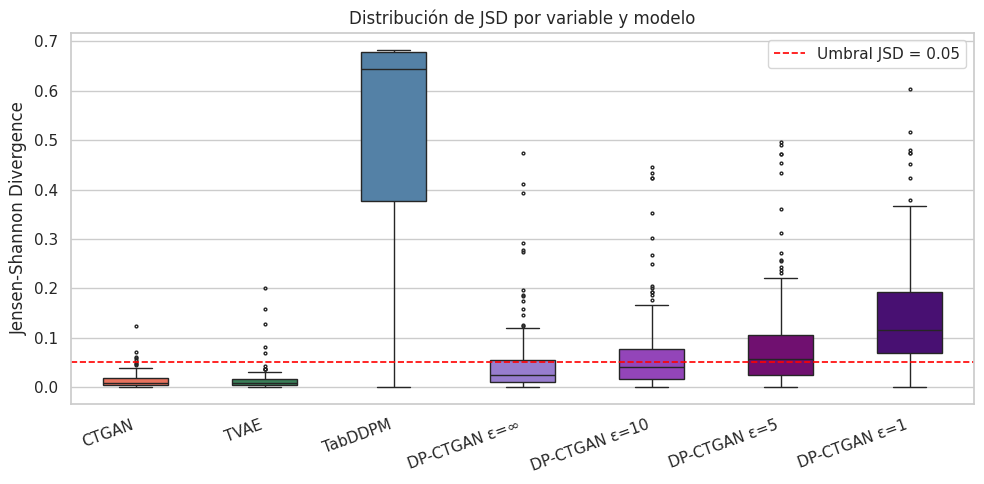

Guardado: reports/fidelidad_jsd_boxplot.png


In [34]:
# Figura: distribuciones de JSD por modelo (boxplot + swarm)
fig, ax = plt.subplots(figsize=(10, 5))
jsd_plot_data = []
for r in marginal_results:
    for v in r['_jsd_vals']:
        jsd_plot_data.append({'model': r['model'], 'JSD': v})
jsd_plot_df = pd.DataFrame(jsd_plot_data)

model_order = list(synth.keys())
palette     = {m: COLORS.get(m, 'gray') for m in model_order}

sns.boxplot(data=jsd_plot_df, x='model', y='JSD', order=model_order,
            palette=palette, width=0.5, fliersize=2, ax=ax)
ax.axhline(0.05, color='red', linestyle='--', linewidth=1.2, label='Umbral JSD = 0.05')
ax.set_xlabel('')
ax.set_ylabel('Jensen-Shannon Divergence')
ax.set_title('Distribución de JSD por variable y modelo')
ax.legend()
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(REPORTS / 'fidelidad_jsd_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: reports/fidelidad_jsd_boxplot.png')

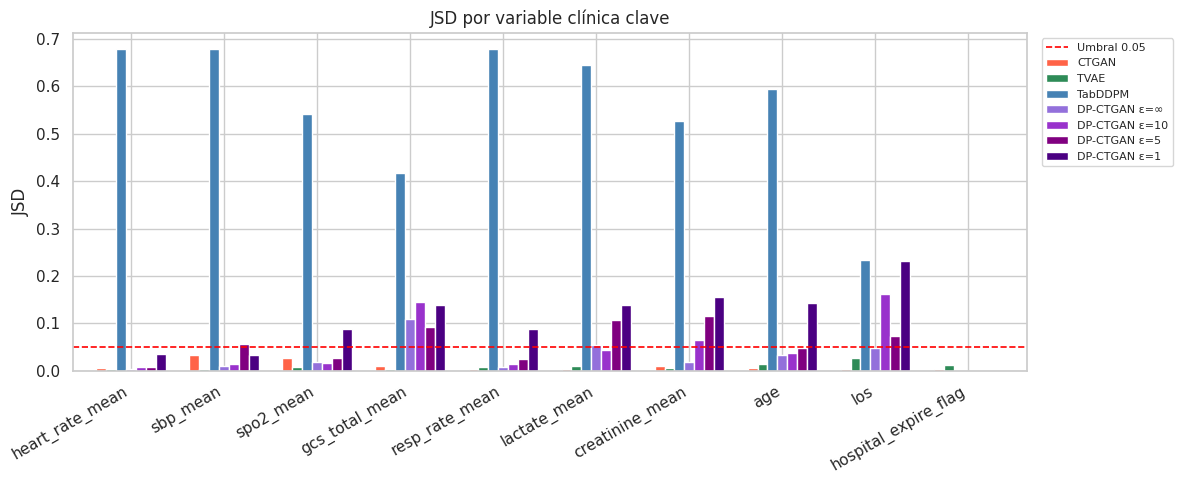

Guardado: reports/fidelidad_jsd_por_variable.png


In [35]:
# Figura: JSD por variable clínica clave (barras comparativas)
KEY_VARS = [
    'heart_rate_mean', 'sbp_mean', 'spo2_mean', 'gcs_total_mean',
    'resp_rate_mean', 'lactate_mean', 'creatinine_mean', 'age', 'los',
    TARGET
]
key_vars = [c for c in KEY_VARS if c in num_cols]

jsd_key = {}
for model_name, df_s in synth.items():
    jsd_key[model_name] = [jsd(real[c].dropna().values, df_s[c].dropna().values)
                           if c in df_s.columns else np.nan for c in key_vars]

jsd_key_df = pd.DataFrame(jsd_key, index=key_vars)

fig, ax = plt.subplots(figsize=(12, 5))
jsd_key_df.plot(kind='bar', ax=ax,
                color=[COLORS.get(m, 'gray') for m in jsd_key_df.columns],
                width=0.75, edgecolor='white')
ax.axhline(0.05, color='red', linestyle='--', linewidth=1.2, label='Umbral 0.05')
ax.set_ylabel('JSD')
ax.set_title('JSD por variable clínica clave')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(REPORTS / 'fidelidad_jsd_por_variable.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: reports/fidelidad_jsd_por_variable.png')

## 3. Distribuciones conjuntas: MMD, Wasserstein-1 y correlaciones

In [36]:
def compute_mmd(X, Y, n_sub=2000):
    """
    MMD² con kernel RBF. Subsamplea a n_sub por eficiencia (O(n²)).
    Sigma estimada con la heurística de la mediana sobre X real.
    """
    rng = np.random.default_rng(42)
    if len(X) > n_sub:
        X = X[rng.choice(len(X), n_sub, replace=False)]
    if len(Y) > n_sub:
        Y = Y[rng.choice(len(Y), n_sub, replace=False)]

    # Heurística de la mediana para sigma
    dists = cdist(X[:500], X[:500], metric='euclidean')
    sigma = np.median(dists[dists > 0])
    if sigma == 0:
        sigma = 1.0

    def rbf(A, B):
        d2 = cdist(A, B, metric='sqeuclidean')
        return np.exp(-d2 / (2 * sigma ** 2))

    k_xx = rbf(X, X).mean()
    k_yy = rbf(Y, Y).mean()
    k_xy = rbf(X, Y).mean()
    return float(k_xx - 2 * k_xy + k_yy)


def compute_wasserstein1_pca(X_real, X_synth, n_components=2):
    """
    Wasserstein-1 sobre las primeras n_components PCA del espacio combinado.
    Promedia W1 sobre cada componente (aproximación 1D).
    """
    X_all = np.vstack([X_real, X_synth])
    pca   = PCA(n_components=n_components, random_state=42)
    pca.fit(X_all)
    Xr_pca = pca.transform(X_real)
    Xs_pca = pca.transform(X_synth)
    w1_per_comp = [stats.wasserstein_distance(Xr_pca[:, i], Xs_pca[:, i])
                   for i in range(n_components)]
    return float(np.mean(w1_per_comp))


# Preparar matriz numérica del dataset real (excluir IDs y categóricas)
X_real_np = real[num_cols].fillna(0).values.astype(np.float32)

joint_results = []
print('Calculando MMD y Wasserstein-1 (puede tardar 1-2 min)...')
for model_name, df_s in synth.items():
    cols_common = [c for c in num_cols if c in df_s.columns]
    X_synth_np  = df_s[cols_common].fillna(0).values.astype(np.float32)
    X_real_sub  = real[cols_common].fillna(0).values.astype(np.float32)

    mmd = compute_mmd(X_real_sub, X_synth_np)
    w1  = compute_wasserstein1_pca(X_real_sub, X_synth_np)

    joint_results.append({'model': model_name, 'mmd2': mmd, 'w1_pca': w1})
    print(f'  {model_name:<20}  MMD²={mmd:.6f}  W1={w1:.4f}')

joint_df = pd.DataFrame(joint_results).set_index('model')

Calculando MMD y Wasserstein-1 (puede tardar 1-2 min)...


  CTGAN                 MMD²=0.018908  W1=20.6242
  TVAE                  MMD²=0.005251  W1=19.8663
  TabDDPM               MMD²=0.554072  W1=1359.2771
  DP-CTGAN ε=∞          MMD²=0.025628  W1=43.7275
  DP-CTGAN ε=10         MMD²=0.012123  W1=32.2254
  DP-CTGAN ε=5          MMD²=0.027538  W1=28.8215
  DP-CTGAN ε=1          MMD²=0.119059  W1=104.5620


In [37]:
def delta_rho(df_real, df_synth, cols):
    """MAE entre matrices de correlación de Pearson (Eq. 5.6 en la memoria)."""
    cols = [c for c in cols if c in df_real.columns and c in df_synth.columns]
    C_r  = df_real[cols].corr(method='pearson').values
    C_s  = df_synth[cols].corr(method='pearson').values
    mask = ~np.isnan(C_r) & ~np.isnan(C_s)
    return float(np.mean(np.abs(C_r[mask] - C_s[mask])))


# Variables clínicas para correlaciones (excluir IDs y target)
corr_cols = [c for c in num_cols if c != TARGET]

corr_results = []
for model_name, df_s in synth.items():
    dr = delta_rho(real, df_s, corr_cols)
    corr_results.append({'model': model_name, 'delta_rho': dr})
    print(f'  {model_name:<20}  Δρ = {dr:.4f}')

corr_df = pd.DataFrame(corr_results).set_index('model')

# Verificación clínica: preservación de correlaciones diagnósticas clave
CLINICAL_PAIRS = [
    ('gcs_total_mean', TARGET),
    ('lactate_mean',   TARGET),
    ('bun_mean',       TARGET),
]
print('\nCorrelaciones diagnósticas (real vs sintético):')
header = f"  {'Par':<35} {'Real':>8}"
for m in synth:
    header += f"  {m[:10]:>10}"
print(header)
for v1, v2 in CLINICAL_PAIRS:
    if v1 not in real.columns or v2 not in real.columns:
        continue
    r_corr = real[[v1, v2]].corr().iloc[0, 1]
    row    = f"  {v1+' vs '+v2:<35} {r_corr:>8.3f}"
    for m, df_s in synth.items():
        if v1 in df_s.columns and v2 in df_s.columns:
            s_corr = df_s[[v1, v2]].corr().iloc[0, 1]
            row   += f"  {s_corr:>10.3f}"
    print(row)

  CTGAN                 Δρ = 0.0590
  TVAE                  Δρ = 0.0351
  TabDDPM               Δρ = 0.0555
  DP-CTGAN ε=∞          Δρ = 0.0664
  DP-CTGAN ε=10         Δρ = 0.1441
  DP-CTGAN ε=5          Δρ = 0.1729
  DP-CTGAN ε=1          Δρ = 0.4205

Correlaciones diagnósticas (real vs sintético):
  Par                                     Real       CTGAN        TVAE     TabDDPM  DP-CTGAN ε  DP-CTGAN ε  DP-CTGAN ε  DP-CTGAN ε
  gcs_total_mean vs hospital_expire_flag   -0.284      -0.225      -0.239      -0.165
  lactate_mean vs hospital_expire_flag    0.194       0.160       0.146       0.140
  bun_mean vs hospital_expire_flag       0.202       0.230       0.240       0.292


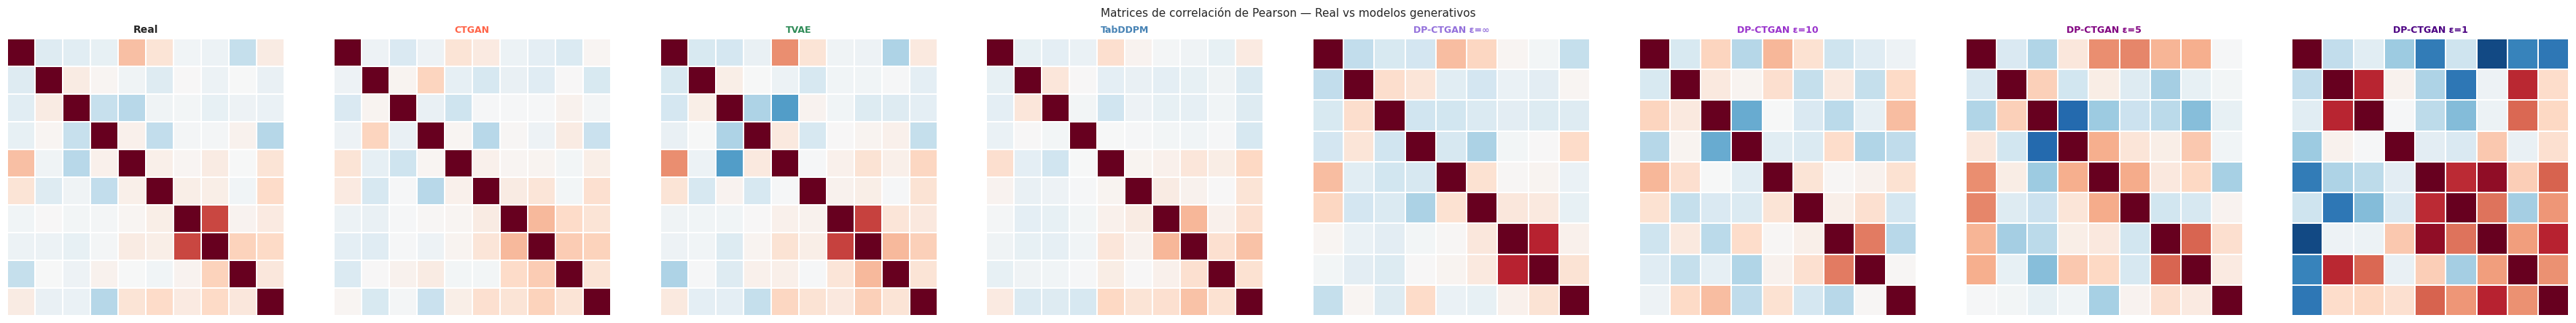

Guardado: reports/fidelidad_correlation_heatmaps.png


In [38]:
# Figura: heatmaps de correlación comparados (real + un modelo por fila)
HEATMAP_VARS = [
    'heart_rate_mean', 'sbp_mean', 'spo2_mean', 'gcs_total_mean',
    'resp_rate_mean', 'lactate_mean', 'creatinine_mean', 'bun_mean',
    'age', TARGET
]
hm_vars = [c for c in HEATMAP_VARS if c in real.columns]
n_models = len(synth)

fig, axes = plt.subplots(1, n_models + 1, figsize=((n_models + 1) * 4.5, 4.5))
if n_models == 0:
    print('Sin modelos disponibles para heatmap.')
else:
    vmin, vmax = -1, 1
    C_real = real[hm_vars].corr(method='pearson')
    sns.heatmap(C_real, ax=axes[0], cmap='RdBu_r', vmin=vmin, vmax=vmax,
                square=True, linewidths=0.3, cbar=False,
                xticklabels=False, yticklabels=False)
    axes[0].set_title('Real', fontsize=10, fontweight='bold')

    for ax, (model_name, df_s) in zip(axes[1:], synth.items()):
        cols_hm = [c for c in hm_vars if c in df_s.columns]
        C_s     = df_s[cols_hm].corr(method='pearson')
        sns.heatmap(C_s, ax=ax, cmap='RdBu_r', vmin=vmin, vmax=vmax,
                    square=True, linewidths=0.3, cbar=False,
                    xticklabels=False, yticklabels=False)
        ax.set_title(model_name, fontsize=9,
                     color=COLORS.get(model_name, 'black'), fontweight='bold')

    fig.suptitle('Matrices de correlación de Pearson — Real vs modelos generativos',
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(REPORTS / 'fidelidad_correlation_heatmaps.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Guardado: reports/fidelidad_correlation_heatmaps.png')

## 4. Análisis visual: UMAP y t-SNE

Calculando proyecciones UMAP...


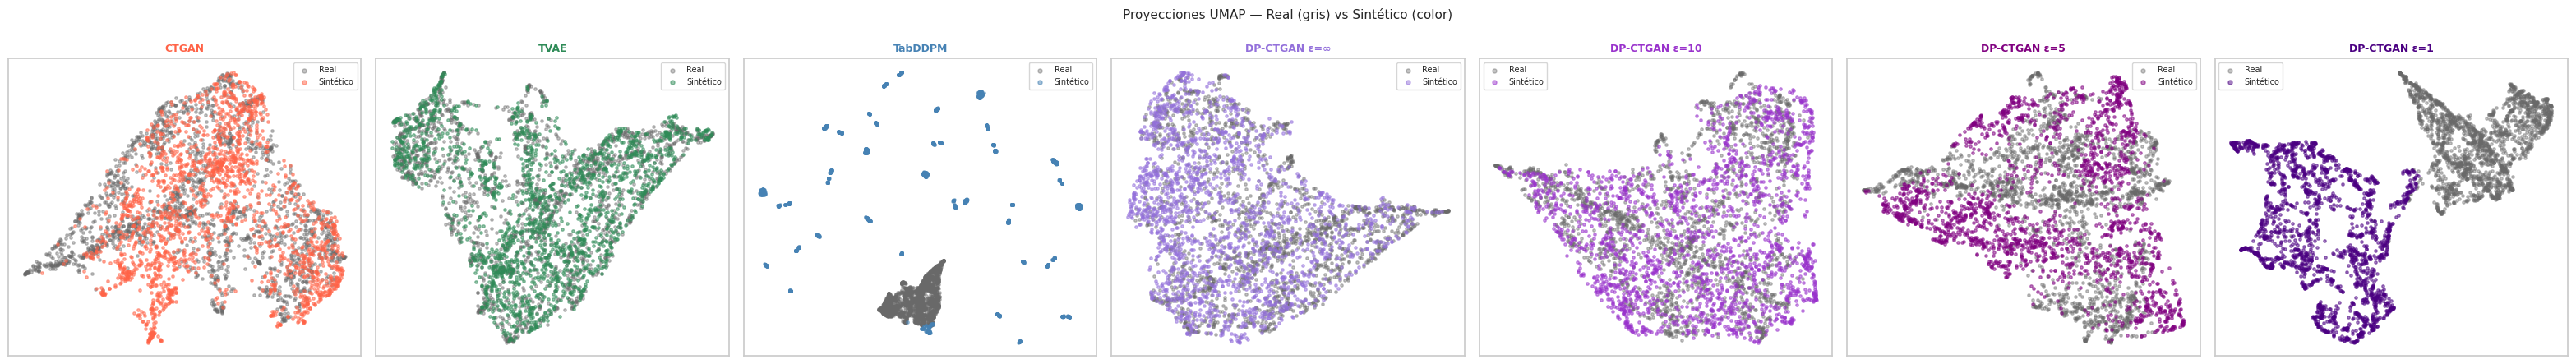

Guardado: reports/fidelidad_umap.png


In [39]:
# Reducción de dimensionalidad — parámetros del §5.1.4 de la memoria
N_VIZ     = 2000   # muestras por dataset para visualización
N_PCA_PRE = 50     # componentes PCA previos a t-SNE

def prep_viz_data(df_real, df_synth, n=N_VIZ, cols=None):
    """Construye dataset mixto balanceado (n real + n sintético) para proyección conjunta."""
    if cols is None:
        cols = [c for c in num_cols if c in df_synth.columns]
    rng   = np.random.default_rng(42)
    idx_r = rng.choice(len(df_real),  min(n, len(df_real)),  replace=False)
    idx_s = rng.choice(len(df_synth), min(n, len(df_synth)), replace=False)
    X_r   = df_real.iloc[idx_r][cols].fillna(0).values
    X_s   = df_synth.iloc[idx_s][cols].fillna(0).values
    X     = np.vstack([X_r, X_s]).astype(np.float32)
    labels = np.array(['Real'] * len(idx_r) + ['Sintético'] * len(idx_s))
    return X, labels


print('Calculando proyecciones UMAP...')
n_models = len(synth)
if n_models > 0:
    fig, axes = plt.subplots(1, n_models, figsize=(n_models * 4.5, 4.5))
    if n_models == 1:
        axes = [axes]

    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42, verbose=False)

    for ax, (model_name, df_s) in zip(axes, synth.items()):
        X_mix, labels = prep_viz_data(real, df_s)
        emb = reducer.fit_transform(X_mix)

        for lbl, color, alpha, size in [
            ('Real',      COLORS['Real'],                 0.4, 6),
            ('Sintético', COLORS.get(model_name, 'blue'), 0.5, 6)
        ]:
            mask = labels == lbl
            ax.scatter(emb[mask, 0], emb[mask, 1],
                       c=color, alpha=alpha, s=size, label=lbl)

        ax.set_title(model_name, fontsize=9,
                     color=COLORS.get(model_name, 'black'), fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.legend(fontsize=7, markerscale=1.5)

    fig.suptitle('Proyecciones UMAP — Real (gris) vs Sintético (color)', fontsize=11)
    plt.tight_layout()
    plt.savefig(REPORTS / 'fidelidad_umap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Guardado: reports/fidelidad_umap.png')

Calculando proyecciones t-SNE (puede tardar varios minutos)...


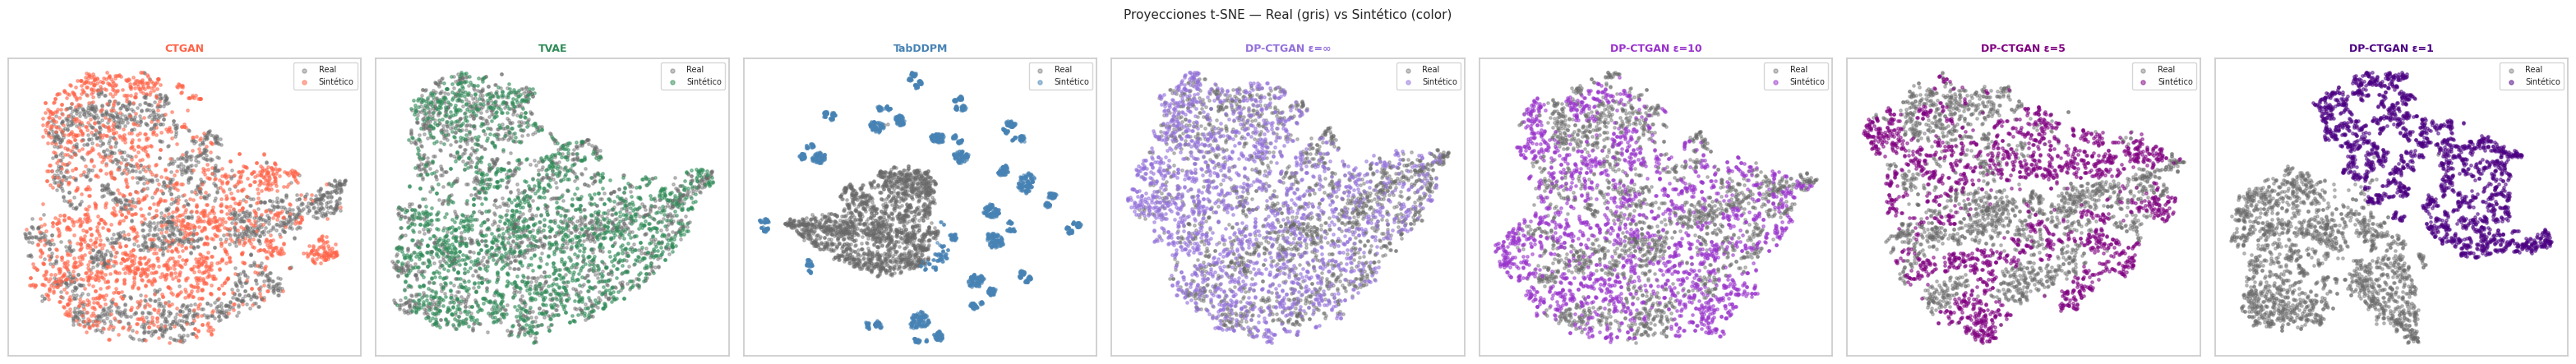

Guardado: reports/fidelidad_tsne.png


In [40]:
print('Calculando proyecciones t-SNE (puede tardar varios minutos)...')
if n_models > 0:
    fig, axes = plt.subplots(1, n_models, figsize=(n_models * 4.5, 4.5))
    if n_models == 1:
        axes = [axes]

    for ax, (model_name, df_s) in zip(axes, synth.items()):
        X_mix, labels = prep_viz_data(real, df_s)

        # PCA previo para reducir coste t-SNE (§5.1.4: 50 componentes)
        n_pca = min(N_PCA_PRE, X_mix.shape[1])
        X_pca = PCA(n_components=n_pca, random_state=42).fit_transform(X_mix)

        tsne = TSNE(n_components=2, perplexity=30, random_state=42,
                    max_iter=1000, verbose=0)
        emb  = tsne.fit_transform(X_pca)

        for lbl, color, alpha, size in [
            ('Real',      COLORS['Real'],                 0.4, 6),
            ('Sintético', COLORS.get(model_name, 'blue'), 0.5, 6)
        ]:
            mask = labels == lbl
            ax.scatter(emb[mask, 0], emb[mask, 1],
                       c=color, alpha=alpha, s=size, label=lbl)

        ax.set_title(model_name, fontsize=9,
                     color=COLORS.get(model_name, 'black'), fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.legend(fontsize=7, markerscale=1.5)

    fig.suptitle('Proyecciones t-SNE — Real (gris) vs Sintético (color)', fontsize=11)
    plt.tight_layout()
    plt.savefig(REPORTS / 'fidelidad_tsne.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Guardado: reports/fidelidad_tsne.png')

## 5. Test de discriminación (XGBoost real vs. sintético)

In [41]:
def discriminator_test(df_real, df_synth, cols, model_name=''):
    """
    Entrena XGBoost para separar real (1) de sintético (0).
    Devuelve AUC-ROC, importancia de features y predicciones de test.
    AUC objetivo: 0.5 (indistinguible). AUC > 0.75 indica fidelidad baja.
    """
    cols = [c for c in cols if c in df_synth.columns]
    N    = min(len(df_real), len(df_synth))

    rng   = np.random.default_rng(42)
    idx_r = rng.choice(len(df_real),  N, replace=False)
    idx_s = rng.choice(len(df_synth), N, replace=False)

    X = np.vstack([
        df_real.iloc[idx_r][cols].fillna(0).values,
        df_synth.iloc[idx_s][cols].fillna(0).values,
    ]).astype(np.float32)
    y = np.array([1] * N + [0] * N)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    clf = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, verbosity=0
    )
    clf.fit(X_tr, y_tr)

    y_prob = clf.predict_proba(X_te)[:, 1]
    auc    = roc_auc_score(y_te, y_prob)

    importance = pd.Series(clf.feature_importances_, index=cols)

    return {'auc': auc, 'importance': importance, 'y_te': y_te, 'y_prob': y_prob}


disc_cols = [c for c in num_cols if c != TARGET]
disc_results = {}

print(f'Test de discriminación XGBoost (AUC objetivo ≈ 0.50):')
for model_name, df_s in synth.items():
    res = discriminator_test(real, df_s, disc_cols, model_name)
    disc_results[model_name] = res
    flag = '' if res['auc'] < 0.65 else ('  ⚠ fidelidad moderada' if res['auc'] < 0.75 else '  ✗ fidelidad baja')
    print(f'  {model_name:<20}  AUC = {res["auc"]:.4f}{flag}')

Test de discriminación XGBoost (AUC objetivo ≈ 0.50):
  CTGAN                 AUC = 1.0000  ✗ fidelidad baja


  TVAE                  AUC = 1.0000  ✗ fidelidad baja
  TabDDPM               AUC = 1.0000  ✗ fidelidad baja
  DP-CTGAN ε=∞          AUC = 1.0000  ✗ fidelidad baja
  DP-CTGAN ε=10         AUC = 1.0000  ✗ fidelidad baja
  DP-CTGAN ε=5          AUC = 1.0000  ✗ fidelidad baja
  DP-CTGAN ε=1          AUC = 1.0000  ✗ fidelidad baja


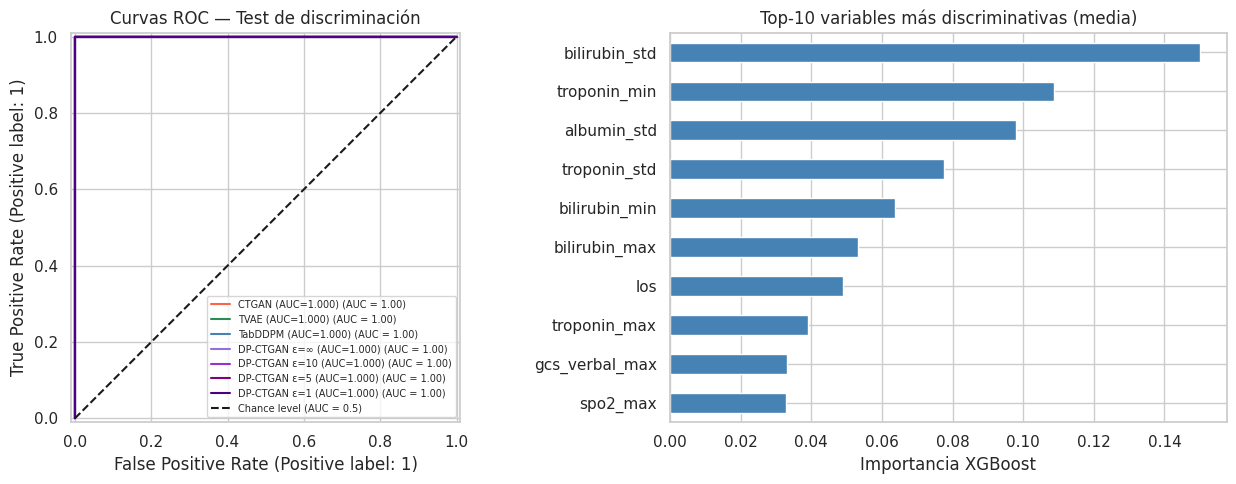

Guardado: reports/fidelidad_discriminator.png


In [42]:
# Figura: curvas ROC comparadas
if disc_results:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Curvas ROC
    ax = axes[0]
    for model_name, res in disc_results.items():
        RocCurveDisplay.from_predictions(
            res['y_te'], res['y_prob'],
            name=f"{model_name} (AUC={res['auc']:.3f})",
            color=COLORS.get(model_name, 'gray'),
            ax=ax, plot_chance_level=(model_name == list(disc_results.keys())[-1])
        )
    ax.set_title('Curvas ROC — Test de discriminación')
    ax.legend(fontsize=7, loc='lower right')

    # Top-10 variables más discriminativas (media sobre modelos disponibles)
    ax2 = axes[1]
    imp_mean = pd.concat([r['importance'] for r in disc_results.values()], axis=1)
    imp_mean.columns = list(disc_results.keys())
    top10 = imp_mean.mean(axis=1).nlargest(10)
    top10.sort_values().plot(kind='barh', ax=ax2, color='steelblue')
    ax2.set_title('Top-10 variables más discriminativas (media)')
    ax2.set_xlabel('Importancia XGBoost')

    plt.tight_layout()
    plt.savefig(REPORTS / 'fidelidad_discriminator.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Guardado: reports/fidelidad_discriminator.png')

## 6. Tabla resumen de fidelidad

In [43]:
# Consolidar todas las métricas en una tabla por modelo
rows = []
for model_name in synth:
    row = {'Modelo': model_name}

    if model_name in marginal_df.index:
        row['JSD mediana']     = marginal_df.loc[model_name, 'jsd_median']
        row['KS mediana']      = marginal_df.loc[model_name, 'ks_median']
        row['KS % rechazado']  = marginal_df.loc[model_name, 'ks_pval_pct_rejected']

    if model_name in joint_df.index:
        row['MMD²']  = joint_df.loc[model_name, 'mmd2']
        row['W1']    = joint_df.loc[model_name, 'w1_pca']

    if model_name in corr_df.index:
        row['Δρ'] = corr_df.loc[model_name, 'delta_rho']

    if model_name in disc_results:
        row['AUC discriminador'] = disc_results[model_name]['auc']

    rows.append(row)

summary = pd.DataFrame(rows).set_index('Modelo')
print('=== TABLA RESUMEN DE FIDELIDAD ===')
print(summary.round(4).to_string())

summary.to_csv(REPORTS / 'fidelidad_summary.csv')
print('\nGuardado: reports/fidelidad_summary.csv')

=== TABLA RESUMEN DE FIDELIDAD ===
               JSD mediana  KS mediana  KS % rechazado    MMD²         W1      Δρ  AUC discriminador
Modelo                                                                                              
CTGAN               0.0080      0.1165         98.3607  0.0189    20.6242  0.0590                1.0
TVAE                0.0085      0.0819         98.3607  0.0053    19.8663  0.0351                1.0
TabDDPM             0.6442      0.5301         99.1803  0.5541  1359.2771  0.0555                1.0
DP-CTGAN ε=∞        0.0251      0.1593        100.0000  0.0256    43.7275  0.0664                1.0
DP-CTGAN ε=10       0.0400      0.1585         99.1736  0.0121    32.2254  0.1441                1.0
DP-CTGAN ε=5        0.0565      0.2194        100.0000  0.0275    28.8215  0.1729                1.0
DP-CTGAN ε=1        0.1157      0.2992        100.0000  0.1191   104.5620  0.4205                1.0

Guardado: reports/fidelidad_summary.csv


In [44]:
# Exportar tabla LaTeX para copiar directamente a la memoria
if not summary.empty:
    latex_str = summary.round(4).to_latex(
        caption='Métricas de fidelidad estadística por modelo generativo.',
        label='tab:fidelidad_summary',
        bold_rows=False,
        escape=True,
    )
    latex_path = REPORTS / 'fidelidad_summary_latex.tex'
    latex_path.write_text(latex_str, encoding='utf-8')
    print(f'Tabla LaTeX guardada: {latex_path}')
    print()
    print(latex_str)

Tabla LaTeX guardada: ../reports/fidelidad_summary_latex.tex

\begin{table}
\caption{Métricas de fidelidad estadística por modelo generativo.}
\label{tab:fidelidad_summary}
\begin{tabular}{lrrrrrrr}
\toprule
 & JSD mediana & KS mediana & KS \% rechazado & MMD² & W1 & Δρ & AUC discriminador \\
Modelo &  &  &  &  &  &  &  \\
\midrule
CTGAN & 0.008000 & 0.116500 & 98.360700 & 0.018900 & 20.624200 & 0.059000 & 1.000000 \\
TVAE & 0.008500 & 0.081900 & 98.360700 & 0.005300 & 19.866300 & 0.035100 & 1.000000 \\
TabDDPM & 0.644200 & 0.530100 & 99.180300 & 0.554100 & 1359.277100 & 0.055500 & 1.000000 \\
DP-CTGAN ε=∞ & 0.025100 & 0.159300 & 100.000000 & 0.025600 & 43.727500 & 0.066400 & 1.000000 \\
DP-CTGAN ε=10 & 0.040000 & 0.158500 & 99.173600 & 0.012100 & 32.225400 & 0.144100 & 1.000000 \\
DP-CTGAN ε=5 & 0.056500 & 0.219400 & 100.000000 & 0.027500 & 28.821500 & 0.172900 & 1.000000 \\
DP-CTGAN ε=1 & 0.115700 & 0.299200 & 100.000000 & 0.119100 & 104.562000 & 0.420500 & 1.000000 \\
\bottomrule
\e